已自动创建picture文件夹

===== 1. 加载鸢尾花数据集 =====
数据集形状: (150, 6)

数据集前5行:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0          山鸢尾  
1        0          山鸢尾  
2        0          山鸢尾  
3        0          山鸢尾  
4        0          山鸢尾  

数据集描述性统计:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000        

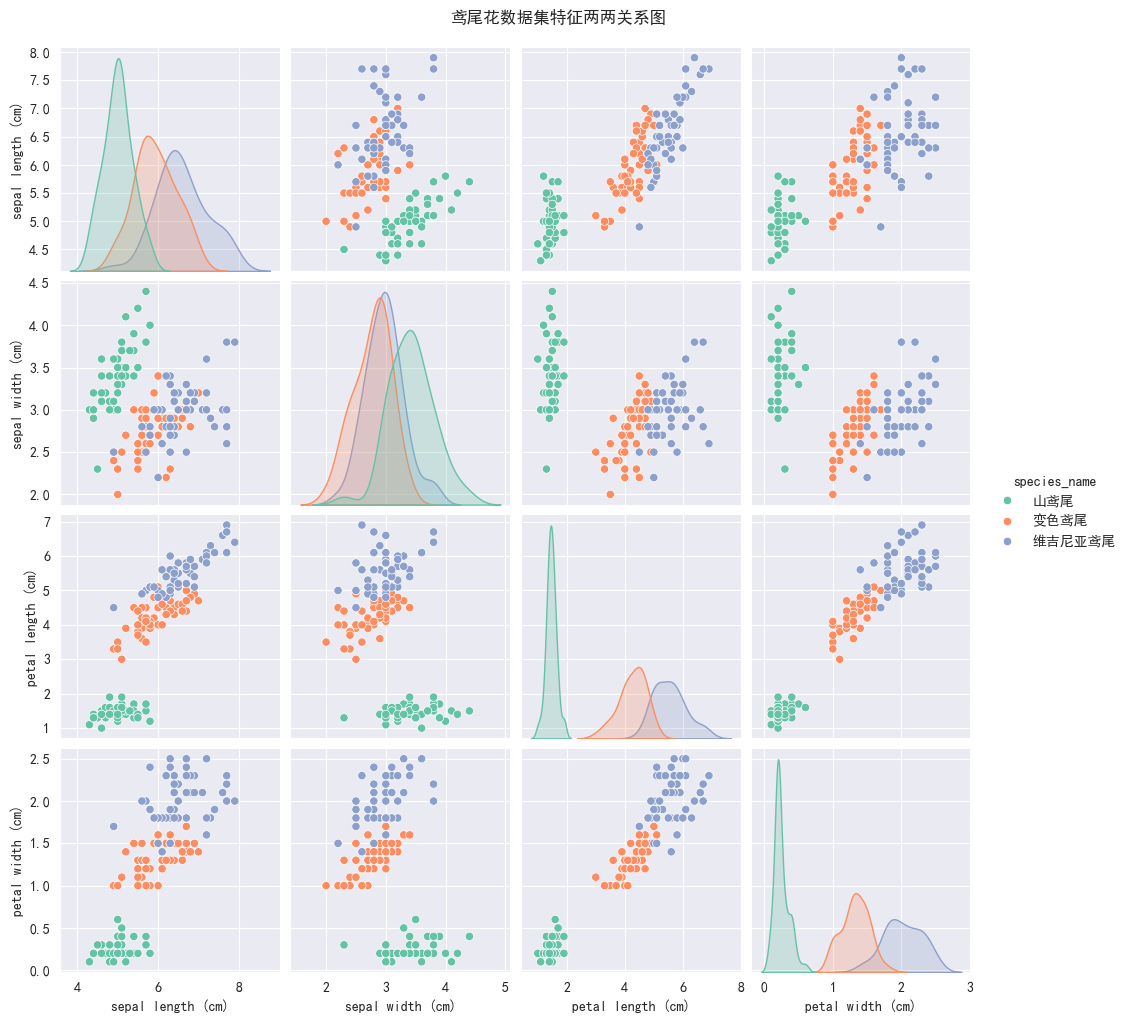


Pairplot分析结论：
1. 山鸢尾（setosa）在花瓣长度/宽度上与其他两种有明显区分，可线性分离；
2. 变色鸢尾（versicolor）和维吉尼亚鸢尾（virginica）在部分特征上有重叠；
3. 花瓣相关特征（长度/宽度）对物种区分的贡献比花萼特征更大。


===== 3. 逻辑回归二分类 =====
训练集准确率: 1.0000
测试集准确率: 1.0000
模型系数: [[ 0.52740109 -0.7890113   2.11344962  0.90535978]]
模型截距: [-6.89369198]


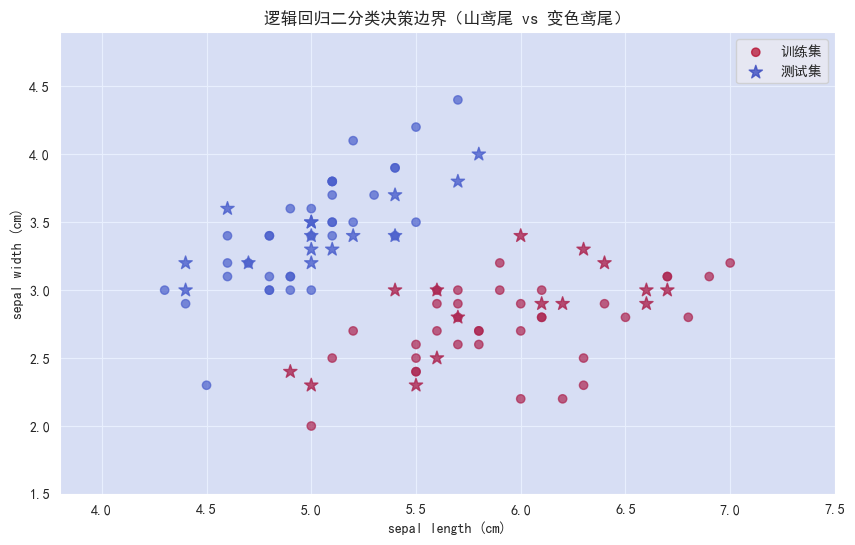


===== 4. 演示线性回归过拟合 =====


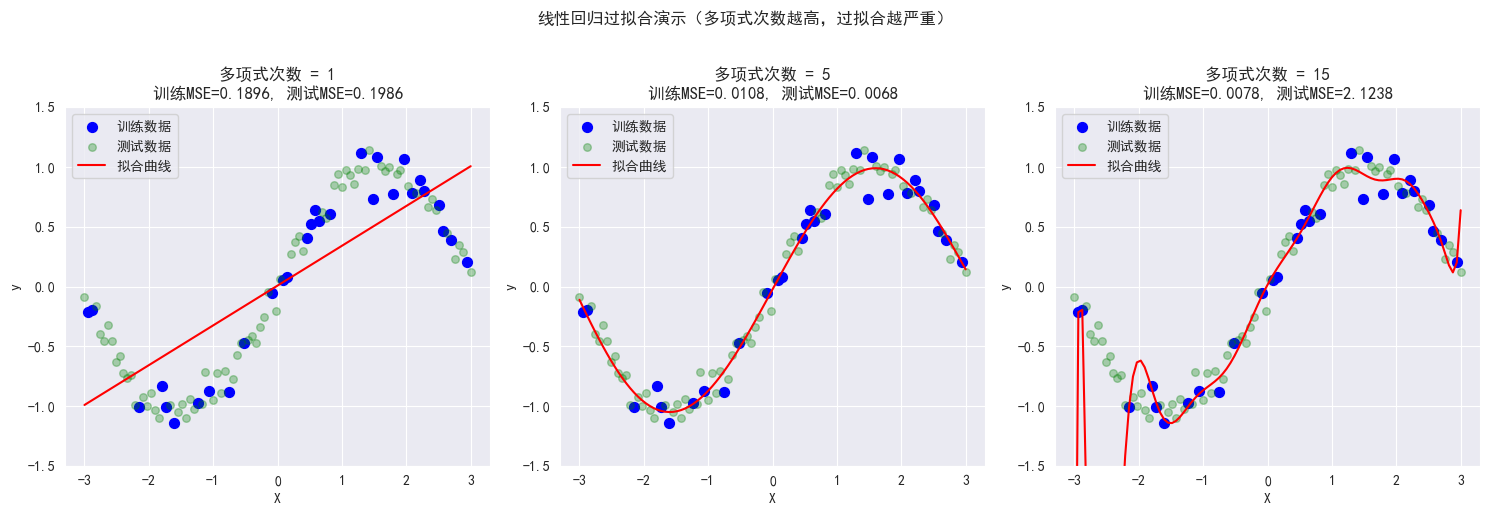


过拟合现象分析：
1. 多项式次数=1（线性）：欠拟合，训练/测试MSE都较高，模型复杂度不足；
2. 多项式次数=5：拟合效果较好，训练/测试MSE都较低，模型复杂度适中；
3. 多项式次数=15：过拟合，训练MSE极低但测试MSE骤增，模型过度学习训练数据的噪声。


===== 理论问题解答 =====

1. 过拟合的核心问题是什么？

        过拟合的核心问题是模型过度拟合训练数据，不仅学习了数据中的真实模式，还学习了训练数据中的噪声和随机波动。
        表现为：模型在训练集上表现极好，但在未见过的测试集上表现极差，泛化能力严重不足。
        本质原因是模型复杂度远高于数据本身的复杂度。
        

2. 为什么我们不能在模型训练所用的数据上评估其质量？

        因为训练数据是模型学习的“素材”，模型会尽可能拟合这些数据（尤其是复杂模型）。
        仅用训练数据评估会高估模型的性能，无法反映模型对新数据的泛化能力。
        正确的做法是将数据划分为训练集和测试集，用训练集训练模型，用测试集评估模型的真实性能。
        

3. 什么是正则化，它如何帮助对抗模型复杂度？

        正则化是一种通过在损失函数中添加惩罚项来限制模型参数大小的技术，目的是降低模型复杂度，防止过拟合。
        常见的正则化方式有L1（Lasso）和L2（Ridge）：
        - L1正则化：惩罚参数的绝对值之和，可使部分参数变为0，实现特征选择；
        - L2正则化：惩罚参数的平方和，使所有参数都趋近于0但不为0，避免参数过大。
        正则化通过约束参数空间，让模型更“简单”，从而减少对训练数据噪声的依赖，提升泛化能力。
        

===== 实验报告关键内容 =====

# 机器学习基础实验报告
## 实验目的
1. 掌握鸢尾花数据集的加载、预处理与可视化方法；
2. 实现逻辑回归模型的构建与二分类任务；
3. 理解并演示线性回归模型的过拟合现象；
4. 掌握Git版本控制的基本流程。

## Git仓库链接
（请替换为你的远程仓库地址，例如：https://github.com/your-username/your-repo）

## 实验结果总结
1

In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
import warnings
import os  # 用于创建文件夹
warnings.filterwarnings('ignore')

# ======================== 关键修改：自动创建picture文件夹 ========================
# 检查picture文件夹是否存在，不存在则创建
if not os.path.exists('picture'):
    os.makedirs('picture')
    print("已自动创建picture文件夹")
else:
    print("picture文件夹已存在")

# 设置中文字体（解决可视化中文显示问题）
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ======================== 1. 加载鸢尾花数据集 ========================
print("\n===== 1. 加载鸢尾花数据集 =====")
# 加载数据集
iris = load_iris()
# 转换为DataFrame方便分析
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
# 将数字标签转换为物种名称
iris_df['species_name'] = iris_df['species'].map({0: '山鸢尾', 1: '变色鸢尾', 2: '维吉尼亚鸢尾'})

# 查看数据集基本信息
print("数据集形状:", iris_df.shape)
print("\n数据集前5行:")
print(iris_df.head())
print("\n数据集描述性统计:")
print(iris_df.describe())
print("\n物种分布:")
print(iris_df['species_name'].value_counts())

# ======================== 2. 构建pairplot表进行数据可视化分析 ========================
print("\n===== 2. 数据可视化（pairplot） =====")
# 绘制pairplot，按物种着色
sns.pairplot(iris_df, hue='species_name', vars=iris.feature_names, palette='Set2')
plt.suptitle('鸢尾花数据集特征两两关系图', y=1.02)
# 修改：保存到picture文件夹
plt.savefig('picture/pairplot_iris.png', dpi=300, bbox_inches='tight')
plt.show()

# 可视化分析说明
print("""
Pairplot分析结论：
1. 山鸢尾（setosa）在花瓣长度/宽度上与其他两种有明显区分，可线性分离；
2. 变色鸢尾（versicolor）和维吉尼亚鸢尾（virginica）在部分特征上有重叠；
3. 花瓣相关特征（长度/宽度）对物种区分的贡献比花萼特征更大。
""")

# ======================== 3. 构建LogisticRegression模型进行二分类 ========================
print("\n===== 3. 逻辑回归二分类 =====")
# 构建二分类数据集：选择山鸢尾（0）和变色鸢尾（1）作为分类目标
binary_iris = iris_df[iris_df['species'].isin([0, 1])].copy()
X_binary = binary_iris[iris.feature_names]  # 特征
y_binary = binary_iris['species']           # 标签

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.3, random_state=42, stratify=y_binary
)

# 训练逻辑回归模型
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)

# 模型预测与评估
y_train_pred = lr_model.predict(X_train)
y_test_pred = lr_model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")
print(f"模型系数: {lr_model.coef_}")
print(f"模型截距: {lr_model.intercept_}")

# 可视化二分类结果（选取前两个特征）
plt.figure(figsize=(10, 6))
# 绘制训练集数据
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, cmap='coolwarm', label='训练集', alpha=0.7)
# 绘制测试集数据
plt.scatter(X_test.iloc[:, 0], X_test.iloc[:, 1], c=y_test, cmap='coolwarm', label='测试集', marker='*', s=100, alpha=0.8)

# 绘制决策边界（简化版，仅展示思路）
x1_min, x1_max = X_binary.iloc[:, 0].min() - 0.5, X_binary.iloc[:, 0].max() + 0.5
x2_min, x2_max = X_binary.iloc[:, 1].min() - 0.5, X_binary.iloc[:, 1].max() + 0.5
xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
Z = lr_model.predict(np.c_[xx1.ravel(), xx2.ravel(), np.zeros_like(xx1.ravel()), np.zeros_like(xx1.ravel())])
Z = Z.reshape(xx1.shape)
plt.contourf(xx1, xx2, Z, alpha=0.2, cmap='coolwarm')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('逻辑回归二分类决策边界（山鸢尾 vs 变色鸢尾）')
plt.legend()
# 修改：保存到picture文件夹
plt.savefig('picture/logistic_regression_binary.png', dpi=300, bbox_inches='tight')
plt.show()

# ======================== 4. 展示线性回归模型的过拟合现象 ========================
print("\n===== 4. 演示线性回归过拟合 =====")
# 生成模拟数据（非线性关系）
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1, 1)  # 自变量
y = np.sin(X).ravel() + np.random.normal(0, 0.1, size=X.shape[0])  # 因变量（带噪声）

# 划分训练集（少量样本）和测试集
X_train_small, X_test, y_train_small, y_test = train_test_split(
    X, y, test_size=0.7, random_state=42
)

# 定义不同复杂度的多项式特征
degrees = [1, 5, 15]  # 低复杂度、中复杂度、高复杂度
plt.figure(figsize=(15, 5))

for i, degree in enumerate(degrees):
    # 生成多项式特征
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_small)
    X_test_poly = poly.transform(X_test)
    X_full_poly = poly.transform(X)  # 用于绘制拟合曲线

    # 训练线性回归模型
    lr = LinearRegression()
    lr.fit(X_train_poly, y_train_small)

    # 预测并计算MSE
    y_train_pred = lr.predict(X_train_poly)
    y_test_pred = lr.predict(X_test_poly)
    train_mse = mean_squared_error(y_train_small, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # 绘制结果
    plt.subplot(1, 3, i+1)
    plt.scatter(X_train_small, y_train_small, label='训练数据', color='blue', s=50)
    plt.scatter(X_test, y_test, label='测试数据', color='green', alpha=0.3, s=30)
    plt.plot(X, lr.predict(X_full_poly), color='red', label='拟合曲线')
    plt.title(f'多项式次数 = {degree}\n训练MSE={train_mse:.4f}, 测试MSE={test_mse:.4f}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.ylim(-1.5, 1.5)

plt.suptitle('线性回归过拟合演示（多项式次数越高，过拟合越严重）', y=1.02)
plt.tight_layout()
# 修改：保存到picture文件夹
plt.savefig('picture/overfitting_demo.png', dpi=300, bbox_inches='tight')
plt.show()

print("""
过拟合现象分析：
1. 多项式次数=1（线性）：欠拟合，训练/测试MSE都较高，模型复杂度不足；
2. 多项式次数=5：拟合效果较好，训练/测试MSE都较低，模型复杂度适中；
3. 多项式次数=15：过拟合，训练MSE极低但测试MSE骤增，模型过度学习训练数据的噪声。
""")

# ======================== 理论问题解答 ========================
print("\n===== 理论问题解答 =====")
theory_answers = {
    "1. 过拟合的核心问题是什么？":
        """
        过拟合的核心问题是模型过度拟合训练数据，不仅学习了数据中的真实模式，还学习了训练数据中的噪声和随机波动。
        表现为：模型在训练集上表现极好，但在未见过的测试集上表现极差，泛化能力严重不足。
        本质原因是模型复杂度远高于数据本身的复杂度。
        """,
    "2. 为什么我们不能在模型训练所用的数据上评估其质量？":
        """
        因为训练数据是模型学习的“素材”，模型会尽可能拟合这些数据（尤其是复杂模型）。
        仅用训练数据评估会高估模型的性能，无法反映模型对新数据的泛化能力。
        正确的做法是将数据划分为训练集和测试集，用训练集训练模型，用测试集评估模型的真实性能。
        """,
    "3. 什么是正则化，它如何帮助对抗模型复杂度？":
        """
        正则化是一种通过在损失函数中添加惩罚项来限制模型参数大小的技术，目的是降低模型复杂度，防止过拟合。
        常见的正则化方式有L1（Lasso）和L2（Ridge）：
        - L1正则化：惩罚参数的绝对值之和，可使部分参数变为0，实现特征选择；
        - L2正则化：惩罚参数的平方和，使所有参数都趋近于0但不为0，避免参数过大。
        正则化通过约束参数空间，让模型更“简单”，从而减少对训练数据噪声的依赖，提升泛化能力。
        """
}

for question, answer in theory_answers.items():
    print(f"\n{question}")
    print(answer)

# ======================== 实验报告关键内容 ========================
print("\n===== 实验报告关键内容 =====")
report = f"""
# 机器学习基础实验报告
## 实验目的
1. 掌握鸢尾花数据集的加载、预处理与可视化方法；
2. 实现逻辑回归模型的构建与二分类任务；
3. 理解并演示线性回归模型的过拟合现象；
4. 掌握Git版本控制的基本流程。

## Git仓库链接
（请替换为你的远程仓库地址，例如：https://github.com/your-username/your-repo）

## 实验结果总结
1. 数据可视化：鸢尾花数据集的花瓣特征对物种区分更有效，山鸢尾可与其他两种线性分离；
2. 逻辑回归二分类：在山鸢尾vs变色鸢尾任务中，模型训练集准确率{train_acc:.4f}，测试集准确率{test_acc:.4f}，泛化效果良好；
3. 过拟合演示：多项式次数越高，模型对训练数据拟合越好，但对测试数据预测误差越大，体现了过拟合的核心特征。

## 结论
1. 数据可视化是理解数据分布、特征相关性的重要手段；
2. 逻辑回归是简单高效的二分类模型，适用于线性可分的数据；
3. 模型复杂度需与数据复杂度匹配，过高的复杂度会导致过拟合；
4. 正则化、数据增强、早停等方法可有效缓解过拟合问题。
"""

print(report)